Shape of the dataset: (569, 31)
   target  radius_mean  texture_mean  perimeter_mean  area_mean  \
0       0        17.99         10.38          122.80     1001.0   
1       0        20.57         17.77          132.90     1326.0   
2       0        19.69         21.25          130.00     1203.0   
3       0        11.42         20.38           77.58      386.1   
4       0        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   symmetry_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0         0.2419  ...         2

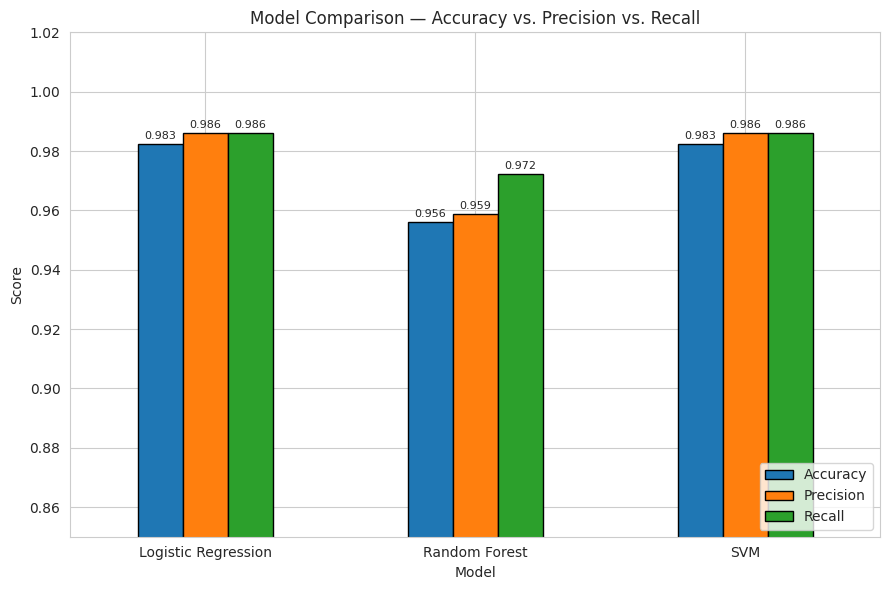

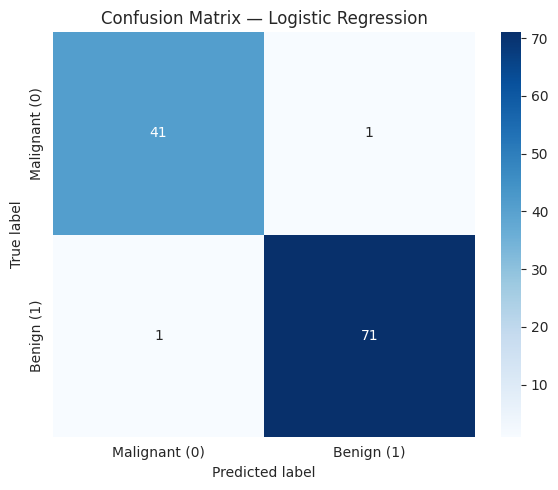

True Negatives:  41
False Positives: 1
False Negatives: 1
True Positives:  71


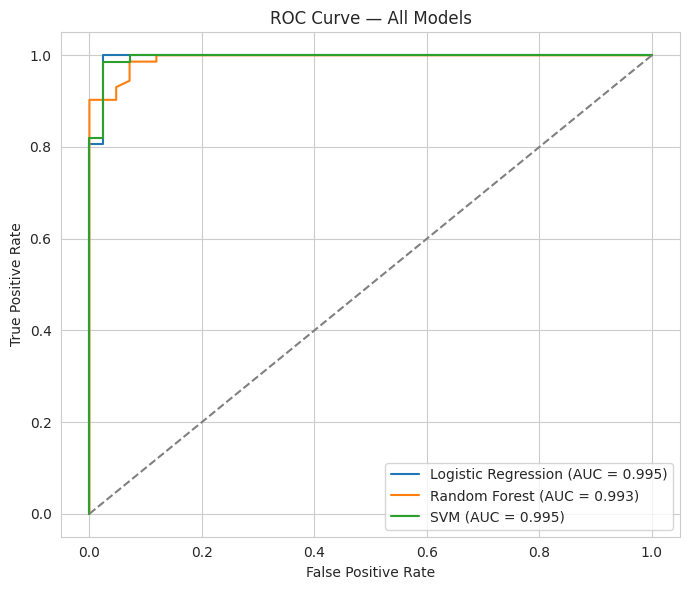

In [19]:
# =============================================================================
# Comparative Analysis of ML Classifiers for Medical Diagnosis
# --- Core libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, roc_curve, auc

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Fix the random state everywhere so results are reproducible
RANDOM_STATE = 42

# Load dataset
df = pd.read_csv('/content/breast_cancer_wisconsin_dataset(1).csv')

# Drop irrelevant columns like 'id' and 'Unnamed: 32'
df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

# Map 'diagnosis' to numerical 'target' (M:0, B:1)
# This checks if 'diagnosis' column exists before mapping
if 'diagnosis' in df.columns:
    df['diagnosis'] = df['diagnosis'].map({'M': 0, 'B': 1})
    df = df.rename(columns={'diagnosis': 'target'}) # Rename for consistency

print(f"Shape of the dataset: {df.shape}")
print(df.head())

# Check for missing values
missing_counts = df.isnull().sum()
missing_cols = missing_counts[missing_counts > 0]

if missing_cols.empty:
    print("\nNo missing values found in the dataset.")
else:
    print("\nMissing values detected:")
    print(missing_cols)

# Quick class balance check
class_counts = df["target"].value_counts()
print("\nClass distribution (0 = malignant, 1 = benign):")
print(class_counts)
print(f"Benign ratio: {class_counts[1] / len(df):.2%}")

# Correlation matrix — top 5 features vs. target
corr_with_target = df.corr()["target"].drop("target")
top5_features = corr_with_target.abs().sort_values(ascending=False).head(5)

print("\nTop 5 features most correlated with the target:")
print(top5_features)

top5_feature_names = top5_features.index.tolist()

# Train/test split and feature scaling
X = df.drop(columns="target")
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled = scaler.transform(X_test)          # transform only on test

print(f"\nTraining samples: {X_train_scaled.shape[0]}")
print(f"Test samples:     {X_test_scaled.shape[0]}")


# Dictionary of models to train
models = {
    "Logistic Regression": LogisticRegression(random_state=RANDOM_STATE, max_iter=10000),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200),
    "SVM": SVC(random_state=RANDOM_STATE, probability=True),
}

results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    predictions[name] = y_pred
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
    }

    print(f"{name} trained.")

# Results table
results_df = pd.DataFrame(results).T.round(4)  # transpose so models are rows
print("\nModel comparison:")
print(results_df)

# Identify the best model by accuracy
best_model_name = results_df["Accuracy"].idxmax()
print(f"\nBest performing model (by accuracy): {best_model_name}")

# Model comparison bar chart
ax = results_df.plot(kind="bar", figsize=(9, 6), rot=0, edgecolor="black")
ax.set_title("Model Comparison — Accuracy vs. Precision vs. Recall")
ax.set_ylabel("Score")
ax.set_xlabel("Model")
ax.set_ylim(0.85, 1.02)  # zoom in a bit since these models all perform well
ax.legend(loc="lower right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=2, fontsize=8)

plt.tight_layout()
plt.show()

# Confusion matrix for the best model
best_preds = predictions[best_model_name]
cm = confusion_matrix(y_test, best_preds)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Malignant (0)", "Benign (1)"],
    yticklabels=["Malignant (0)", "Benign (1)"],
    ax=ax,
)
ax.set_title(f"Confusion Matrix — {best_model_name}")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

# Plot all three models on the same axes to compare AUC directly, using
# predicted probabilities for the positive class (benign = 1).
fig, ax = plt.subplots(figsize=(7, 6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray",)
ax.set_title("ROC Curve — All Models")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

